# Block 3: Anomaly Detection with Autoencoders
## Hochfrequenz AI Workshop

**Objective:** Detect anomalies in smart meter consumption data (fraud, equipment failure, unusual patterns)

**Key Concepts:** ANN building blocks, Encoder-Decoder architecture, Reconstruction error, Unsupervised learning

**Approach:** Train autoencoder on normal patterns → Detect anomalies via high reconstruction error

## Theory: Autoencoders for Anomaly Detection

### The Anomaly Detection Challenge

**Business Problem (Hochfrequenz Context):**
- Smart meters record millions of consumption patterns
- **Fraud:** Meter tampering, illegal connections (5-10% revenue loss in some markets)
- **Equipment Failure:** Malfunctioning meters, detector issues
- **Unusual Patterns:** Vacant homes with consumption, seasonal anomalies

**Traditional Approach:** Rule-based thresholds
- Example: "Flag if consumption > 2x average"
- **Problem:** Misses complex patterns, high false positives

**ML Approach:** Learn what "normal" looks like, flag deviations

-----

### Autoencoder Architecture

**Key Difference:** Autoencoder is **unsupervised**
- Input = Output (reconstruct the input itself)
- No labels needed ("normal" vs "anomaly")

**Architecture: Encoder-Decoder**

```
INPUT (24 hours)  →  ENCODER  →  LATENT (compressed)  →  DECODER  →  OUTPUT (24 hours)
     [500W...]          ↓             [4 dims]              ↓           [510W...]
                  Compression                          Reconstruction
```

**Encoder:**
- Compresses input into low-dimensional representation (latent space)
- Example: 24 hours → 4 numbers
- Learns essential features ("morning peak", "weekend pattern")

**Latent Space:**
- Compressed representation capturing key patterns
- Forces network to learn what's important

**Decoder:**
- Reconstructs original input from latent representation
- Example: 4 numbers → 24 hours
- Tries to recover original pattern

---

### How Anomaly Detection Works

**Training Phase:**
1. Train autoencoder on **normal consumption data only**
2. Network learns to reconstruct typical patterns well
3. Loss = Reconstruction Error (how different is output from input)

**Detection Phase:**
1. Feed new consumption pattern (normal or anomalous)
2. Calculate reconstruction error
3. **If error is high → anomaly** (network can't reconstruct it well)
4. **If error is low → normal** (network recognizes pattern)

**Intuition:**
- Autoencoder is like a "pattern expert" trained on normal behavior
- When it sees something unusual, it struggles to reproduce it
- High reconstruction error = "I don't recognize this pattern!"

---

### Why This Works for Energy

**Normal Consumption Patterns:**
- Daily cycle (morning/evening peaks)
- Weekly cycle (weekday vs weekend)
- Seasonal variation (summer/winter)

**Anomalies:**
- Sudden drop to zero (meter failure)
- 30% reduction (tampering/fraud)
- Flat consumption (detector stuck)
- Irregular spikes (unauthorized connection)

Autoencoder learns normal patterns → flags anything that doesn't fit!

# 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"✅ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully
TensorFlow version: 2.20.0


## 1.1 Load Data (Recap from Block 1)

We'll use the same German household consumption data, but prepare it differently for LSTM (sequences instead of feature vectors)

### 1.1.2 Mount Google Drive
Run these cells only if working from google colab. When working on your machine you'll have access to the folders with the data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#testing
import h5py

#adapt name
path = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2018 Data 60min.hdf5'  
f = h5py.File(path, 'r')

#Top‑level groups (e.g. 'NOPV', 'WITHPV', 'MISCSUBSTATION')
print(list(f.keys()))

g = f['NO_PV']                    # example - changed from NOPV to NO_PV
print(list(g.keys()))            # e.g. ['SFH3', 'SFH4', ...]

sfh3 = g['SFH3']
print(list(sfh3.keys()))         # e.g. ['HOUSEHOLD', 'HEATPUMP']

household = sfh3['HOUSEHOLD']
print(list(household.keys()))    # column names, e.g. ['index', 'P_TOT', 'Q_TOT', 'U_1', ...]
nopv = f['NO_PV']
sfh3 = nopv['SFH3']
household = sfh3['HOUSEHOLD']

timestamps = household['table']['index'][:]          # UNIX seconds
p_active   = household['table']['P_TOT'][:]          # W, active power [file:68]

def load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT'):
    grp = f[top][house][meter]
    return grp['table']['index'][:], grp['table'][column][:]

print(p_active)
inspect = load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT')
print(inspect)

### 1.1.3 Read HDF5 data

In [2]:
import h5py
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Load real data from HDF5
def load_wpuq_household(filepath, house='SFH3', top='NO_PV', meter='HOUSEHOLD'):
    """Load household or heat pump power consumption from WPuQ dataset"""
    with h5py.File(filepath, 'r') as f:
        grp = f[top][house][meter]['table']

        timestamps_unix = grp['index'][:]        # UNIX seconds
        p_active = grp['P_TOT'][:]               # Active power in watts [file:68]
        q_reactive = grp['Q_TOT'][:]             # Reactive power (optional)

    # Convert UNIX timestamps to datetime
    timestamps = pd.to_datetime(timestamps_unix, unit='s')

    # Build DataFrame (similar structure to your dummy data)
    data = pd.DataFrame({
        'timestamp': timestamps,
        'consumption': p_active,              # Your main metric (W)
        'reactive_power': q_reactive,
        'hour': timestamps.hour,
        'day_of_week': timestamps.dayofweek,
        'month': timestamps.month,
        'is_weekend': (timestamps.dayofweek >= 5).astype(int)
    })

    data.set_index('timestamp', inplace=True)
    return data

# 2. Load and inspect
# filepath = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2019 Data 60min.hdf5'
filepath18 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Data 60min.hdf5'
data_2018 = load_wpuq_household(filepath18, house='SFH3', meter='HOUSEHOLD')
filepath19 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Data 60min.hdf5'
data_2019 = load_wpuq_household(filepath19, house='SFH3', meter='HOUSEHOLD')

# 3. Merge data
# 2018 data has Nan's between Jan and April
data_2018 = data_2018[data_2018.index.month >= 6]
data = pd.concat([data_2018, data_2019], axis=0)


print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head(n=15))
print(f"\nConsumption statistics:")
print(data['consumption'].describe())

Dataset shape: (13896, 6)
Date range: 2018-06-01 00:00:00 to 2019-12-31 23:00:00

First 5 rows:
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1            4      6   
2018-06-01 02:00:00    87.512389       -9.645250     2            4      6   
2018-06-01 03:00:00   184.230084       72.585944     3            4      6   
2018-06-01 04:00:00   118.397889       35.135694     4            4      6   
2018-06-01 05:00:00    67.159528      -23.663667     5            4      6   
2018-06-01 06:00:00   134.485889       58.459333     6            4      6   
2018-06-01 07:00:00   418.422585       48.184833     7            4      6   
2018-06-01 08:00:00   323.888027       24.571528     8            4      6   
2018-06-01 09:00:00   715.743057      -21.3035

### Add temperature/combine data
Our data came with the weather data as a different file, so we have to extract it and merge it with our current data_frame

In [3]:
def load_weather(filepath):
    """Load ambient temperature from weather data file"""
    with h5py.File(filepath, 'r') as f:

        table = f['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']
        print(f"Dataset shape: {table.shape}")
        print(f"Available columns (fields): {table.dtype.names}")
        # 2. Load Index

        ts = table['index'][:]
        print(ts)
        temps = table['TEMPERATURE:TOTAL'][:] 

    timestamps = pd.to_datetime(ts, unit='ns')
    temps_df = pd.DataFrame({
        'timestamp':timestamps, 
        'month': timestamps.month,
        'temperature': temps
    })
    temps_df.set_index('timestamp', inplace=True)
    
    # Resample to hourly (H) to match consumption data
    return temps_df.resample('H').mean()

weather_2018 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Weather Data.hdf5')
weather_2019 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Weather Data.hdf5')
weather_2018 = weather_2018[weather_2018.index.month >= 6]
weather_data = pd.concat([weather_2018, weather_2019], axis=0)

print(weather_2019.head())
# You only need the 'temperature' column from the weather data
data = data.join(weather_data[['temperature']], how='left').interpolate()  # Fill gaps
print(data.head())

Dataset shape: (49079,)
Available columns (fields): ('index', 'TEMPERATURE:TOTAL')
[1514764800000000000 1514768400000000000 1514772000000000000 ...
 1546296600000000000 1546296900000000000 1546297200000000000]
Dataset shape: (104549,)
Available columns (fields): ('index', 'TEMPERATURE:TOTAL')
[1546297200000000000 1546297800000000000 1546298100000000000 ...
 1577832600000000000 1577832900000000000 1577833200000000000]
                     month  temperature
timestamp                              
2018-12-31 23:00:00   12.0     8.790000
2019-01-01 00:00:00    1.0     8.011111
2019-01-01 01:00:00    1.0     7.720000
2019-01-01 02:00:00    1.0     7.000000
2019-01-01 03:00:00    1.0     7.170000
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1           

### 1.1.4 Generate realistic synthetic German household consumption data

This mimics the Nature Scientific Data dataset structure

In [ ]:
np.random.seed(42)

# Generate 2 years of hourly data
date_range = pd.date_range(start='2018-05-01', end='2020-12-31', freq='H')
n_samples = len(date_range)

# Create realistic consumption pattern
data = pd.DataFrame({
    'timestamp': date_range,
    'hour': date_range.hour,
    'day_of_week': date_range.dayofweek,
    'month': date_range.month,
    'is_weekend': (date_range.dayofweek >= 5).astype(int)
})

# Base consumption pattern (W) - typical German household
# Morning peak (~7 AM), evening peak (~6-7 PM), low at night
hourly_pattern = np.array([
    300, 280, 250, 240, 250, 350, 550, 700,  # Night to morning
    600, 500, 450, 420, 430, 480, 550, 600,  # Midday
    700, 800, 750, 700, 650, 600, 550, 400   # Evening to night
])

# Apply hourly pattern
data['consumption_base'] = hourly_pattern[data['hour']]

# Add seasonal variation (winter = higher consumption)
seasonal_factor = 1.0 + 0.3 * np.sin(2 * np.pi * (data['month'] - 2) / 12)
data['consumption_seasonal'] = data['consumption_base'] * seasonal_factor

In [ ]:

# Add weekend effect (lower consumption)
data['consumption_adjusted'] = data['consumption_seasonal'] * np.where(data['is_weekend'] == 1, 0.85, 1.0)

# Add random noise and weather effects
data['consumption'] = data['consumption_adjusted'] + np.random.normal(0, 50, n_samples)
data['consumption'] = data['consumption'].clip(lower=50)  # No negative consumption

# Create a simple temperature proxy (correlates with season)
data['temperature'] = 15 + 8 * np.sin(2 * np.pi * (data['month'] - 2) / 12) + np.random.normal(0, 2, n_samples)

# Set timestamp as index
data.set_index('timestamp', inplace=True)

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nConsumption statistics:")
print(data['consumption'].describe())


# 2. Prepare Data for Autoencoder

**Key Difference from Blocks 1-2:**
- We create rolling windows of 24 hours
- Each window is treated as one "sample"
- Autoencoder learns to reconstruct these 24-hour patterns

In [4]:
def create_windows(data, window_size=24):
    """
    Create rolling windows of consumption data.

    Parameters:
    -----------
    data : array
        Time series data (1D)
    window_size : int
        Size of rolling window (default: 24 hours)

    Returns:
    --------
    windows : numpy array (samples, window_size)
        Rolling windows
    """
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# Create 24-hour rolling windows
window_size = 24
consumption_values = np.log(data['consumption'].values)

X_windows = create_windows(consumption_values, window_size=window_size)

print(f"Rolling windows created:")
print(f"  Shape: {X_windows.shape} (samples, hours)")
print(f"  Each sample = {window_size} consecutive hours of consumption")
print(f"\nExample window (first 24 hours):")
print(X_windows[0])

Rolling windows created:
  Shape: (13874, 24) (samples, hours)
  Each sample = 24 consecutive hours of consumption

Example window (first 24 hours):
[4.67808447 4.85348017 4.47178037 5.21618543 4.77405089 4.2070708
 4.90145928 6.03649189 5.78039786 6.57332124 4.92317513 4.79423332
 4.76652911 5.32740883 6.42974985 6.90135277 5.40852698 5.56227715
 5.32151835 5.23081609 4.66240108 5.09864702 4.58448096 4.74254329]


## 2.2 Train-Test Split

**Important:** We use only "normal" data for training
- First 80%: Training (assume all normal)
- Last 20%: Testing (may contain anomalies)

In [5]:
# Chronological split
split_idx = int(len(X_windows) * 0.8)

X_train_normal = X_windows[:split_idx]
X_test = X_windows[split_idx:]

print(f"Train set (normal data): {X_train_normal.shape[0]:,} samples")
print(f"Test set:                 {X_test.shape[0]:,} samples")
print(f"\nTrain set is 100% normal consumption (by assumption)")
print(f"Test set may contain anomalies (we'll inject some later)")

Train set (normal data): 11,099 samples
Test set:                 2,775 samples

Train set is 100% normal consumption (by assumption)
Test set may contain anomalies (we'll inject some later)


## 2.1 Normalize Data

MinMax
Standard

In [6]:
# Normalize windows (important for neural networks)
scaler = MinMaxScaler()
X_train_normal = scaler.fit_transform(X_train_normal)
X_test = scaler.transform(X_test)

print(f"Scaled data:")
print(f"  Mean: {X_train_normal.mean():.4f} (should be ~0 if standard scaler)")
print(f"  Std:  {X_train_normal.std():.4f} (should be ~1 if standard scaler)")
print(f"  Max: {X_train_normal.max():.4f}")
print(f"  Min:  {X_train_normal.min():.4f}")
#print(f"\nExample scaled window:")
#print(X_windows_scaled[0])

Scaled data:
  Mean: 0.3034 (should be ~0 if standard scaler)
  Std:  0.1346 (should be ~1 if standard scaler)
  Max: 1.0000
  Min:  0.0000


# 3. Build Autoencoder Model

**Architecture:**
- Input: 24 hours of consumption
- Encoder: 24 → 16 → 8 → 4 (compression)
- Latent: 4-dimensional representation
- Decoder: 4 → 8 → 16 → 24 (reconstruction)
- Output: 24 hours reconstructed

**Compression Ratio:** 24 → 4 = 6:1 (forces learning of key patterns)

## 3.1 Dense Auto-Encoder

In [ ]:
# Input dimension
input_dim = window_size  # 24
latent_dim = 2  # Compressed representation

# ENCODER: Compress input
encoder = Sequential([
    layers.Dense(16, activation='leaky_relu', input_dim=input_dim, name='encoder_1'),
    layers.Dens(8, activation='leaky_relu', name='encoder_2'),
    layers.Dense(latent_dim, activation='leaky_relu', name='latent')  # Bottleneck
], name='Encoder')

# DECODER: Reconstruct from latent
decoder = Sequential([
    layers.Dense(8, activation='leaky_relu', input_dim=latent_dim, name='decoder_1'),
    layers.Dense(16, activation='leaky_relu', name='decoder_2'),
    layers.Dense(input_dim, activation='linear', name='output')  # Reconstruct 24 hours
], name='Decoder')

# AUTOENCODER: Encoder + Decoder
autoencoder = Sequential([encoder, decoder], name='Autoencoder')

# Compile
autoencoder.compile(
    optimizer='adam',
    loss='mse',  # Reconstruction error
    metrics=['mae']
)

print(autoencoder.summary())
print(f"\nCompression:")
print(f"  Input: {input_dim} dimensions")
print(f"  Latent: {latent_dim} dimensions")
print(f"  Compression ratio: {latent_dim/input_dim:.1%}")
print(f"\nTotal parameters: {autoencoder.count_params():,}")

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder (Sequential)            │ (None, 2)              │           554 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 24)             │           576 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130 (4.41 KB)

 Trainable params: 1,130 (4.41 KB)

 Non-trainable params: 0 (0.00 B)

None

Compression:
  Input: 24 dimensions
  Latent: 2 dimensions
  Compression ratio: 8.3%

Total parameters: 1,130


## 3.2 Convolutional Auto-Encoder

In [ ]:
# Assuming X_train is your dataset
X_train_conv = X_train_normal.reshape((X_train_normal.shape[0], 24, 1))
X_test_conv = X_test.reshape((X_test.shape[0], 24, 1))

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# --- CONFIGURATION ---
window_size = 24    # Time steps
n_features = 1      # Features per step (e.g., consumption value)
input_shape = (window_size, n_features) 
latent_dim = 2      # Bottleneck size

# --- ENCODER ---
conv_encoder = Sequential([
    layers.Input(shape=input_shape),
    
    # Layer 1: Compress 24 steps -> 12 steps
    # Filters=16 means we learn 16 different 'shapes' or patterns
    layers.Conv1D(filters=16, kernel_size=3, strides=2, padding='same', activation='relu'),
    
    # Layer 2: Compress 12 steps -> 6 steps
    layers.Conv1D(filters=8, kernel_size=3, strides=2, padding='same', activation='relu'),
    
    # Flatten to connect to Dense bottleneck
    layers.Flatten(),
    
    # Bottleneck: The compressed latent representation
    layers.Dense(latent_dim, name='latent_space')
], name='Encoder')

# --- DECODER ---
conv_decoder = Sequential([
    layers.Input(shape=(latent_dim,)),
    
    # Expand from latent vector back to spatial structure
    # We need to match the shape of the last Conv1D layer output before flattening
    # Shape target: (6 steps, 8 filters) -> 48 units
    layers.Dense(6 * 8, activation='relu'),
    layers.Reshape((6, 8)),
    
    # Layer 1: Upsample 6 steps -> 12 steps
    layers.Conv1DTranspose(filters=16, kernel_size=3, strides=2, padding='same', activation='relu'),
    
    # Layer 2: Upsample 12 steps -> 24 steps (Original Size)
    # Filters=1 to reconstruct the single consumption feature
    layers.Conv1DTranspose(filters=n_features, kernel_size=3, strides=2, padding='same', activation='linear')
], name='Decoder')

# --- FULL MODEL ---
conv_autoencoder = Sequential([conv_encoder, conv_decoder], name='Conv1D_Autoencoder')

# Compile
conv_autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Print Summary
print(conv_autoencoder.summary())

# Verify Compression
print(f"\nStructure Check:")
print(f"  Input Shape: {input_shape}")
print(f"  Latent Shape: ({latent_dim},)")
print(f"  Total Parameters: {conv_autoencoder.count_params():,}")

# 4. Train Autoencoder on Normal Data

**Key:** Input = Target (unsupervised learning)

In [8]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
model = "autoencoder"
# Train (X_train = input AND target)
if model == 'autoencoder':
    print("Training autoencoder on normal consumption patterns...\n")
    history = autoencoder.fit(
        X_train_normal, X_train_normal,  # Input = Output (unsupervised)
        epochs=50,
        batch_size=7,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    print("\n✅ Autoencoder training complete!")

elif model == 'conv-autoencoder':

    print("Training convolutional autoencoder on normal consumption patterns...\n")
    history = conv_autoencoder.fit(
        X_train_normal, X_train_normal,  # Input = Output (unsupervised)
        epochs=50,
        batch_size=7,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    print("\n✅ Convolutional autoencoder training complete!")


Training autoencoder on normal consumption patterns...

Epoch 1/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 1s 432us/step - loss: 0.0181 - mae: 0.0948 - val_loss: 0.0125 - val_mae: 0.0820
Epoch 2/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - loss: 0.0124 - mae: 0.0798 - val_loss: 0.0118 - val_mae: 0.0801
Epoch 3/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 1s 401us/step - loss: 0.0123 - mae: 0.0793 - val_loss: 0.0118 - val_mae: 0.0799
Epoch 4/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 1s 402us/step - loss: 0.0123 - mae: 0.0793 - val_loss: 0.0118 - val_mae: 0.0801
Epoch 5/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 0.0123 - mae: 0.0793 - val_loss: 0.0118 - val_mae: 0.0802
Epoch 6/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - loss: 0.0121 - mae: 0.0786 - val_loss: 0.0118 - val_mae: 0.0799
Epoch 7/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - loss: 0.0119 - mae: 0.0778 - val_loss: 0.0116 - val_mae: 0.0796
Epoch 8/50
1269/1269 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 0.0118 - mae: 0.0772 - val

## 4.1 Visualize Training History

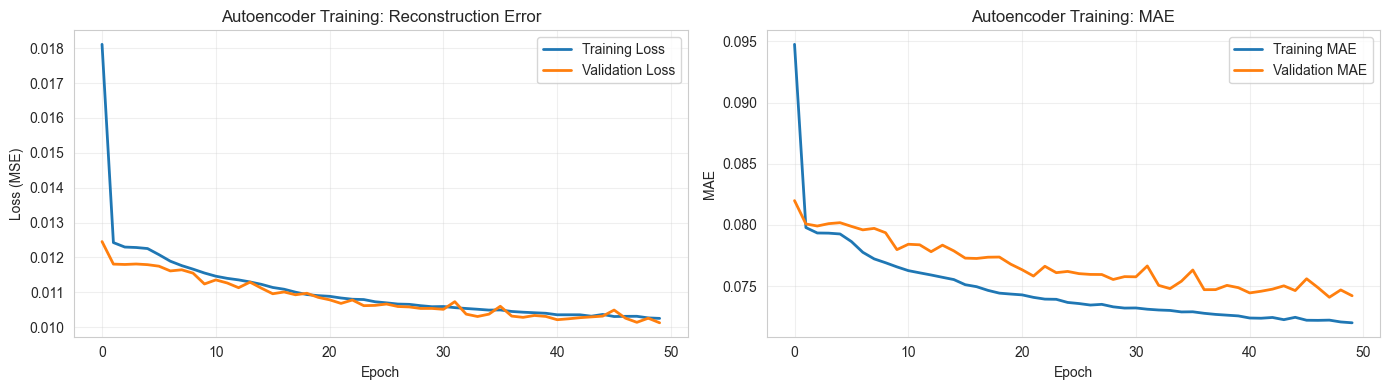


Final validation reconstruction error: 0.010128


In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss (MSE)
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Autoencoder Training: Reconstruction Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Autoencoder Training: MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_loss = history.history['val_loss'][-1]
print(f"\nFinal validation reconstruction error: {final_loss:.6f}")

## 4.2 Visualize Encoder Latent Space

Let's see what the encoder learned (4D latent representation)

Latent space shape: (1000, 2)
  Samples: 1000
  Dimensions: 2


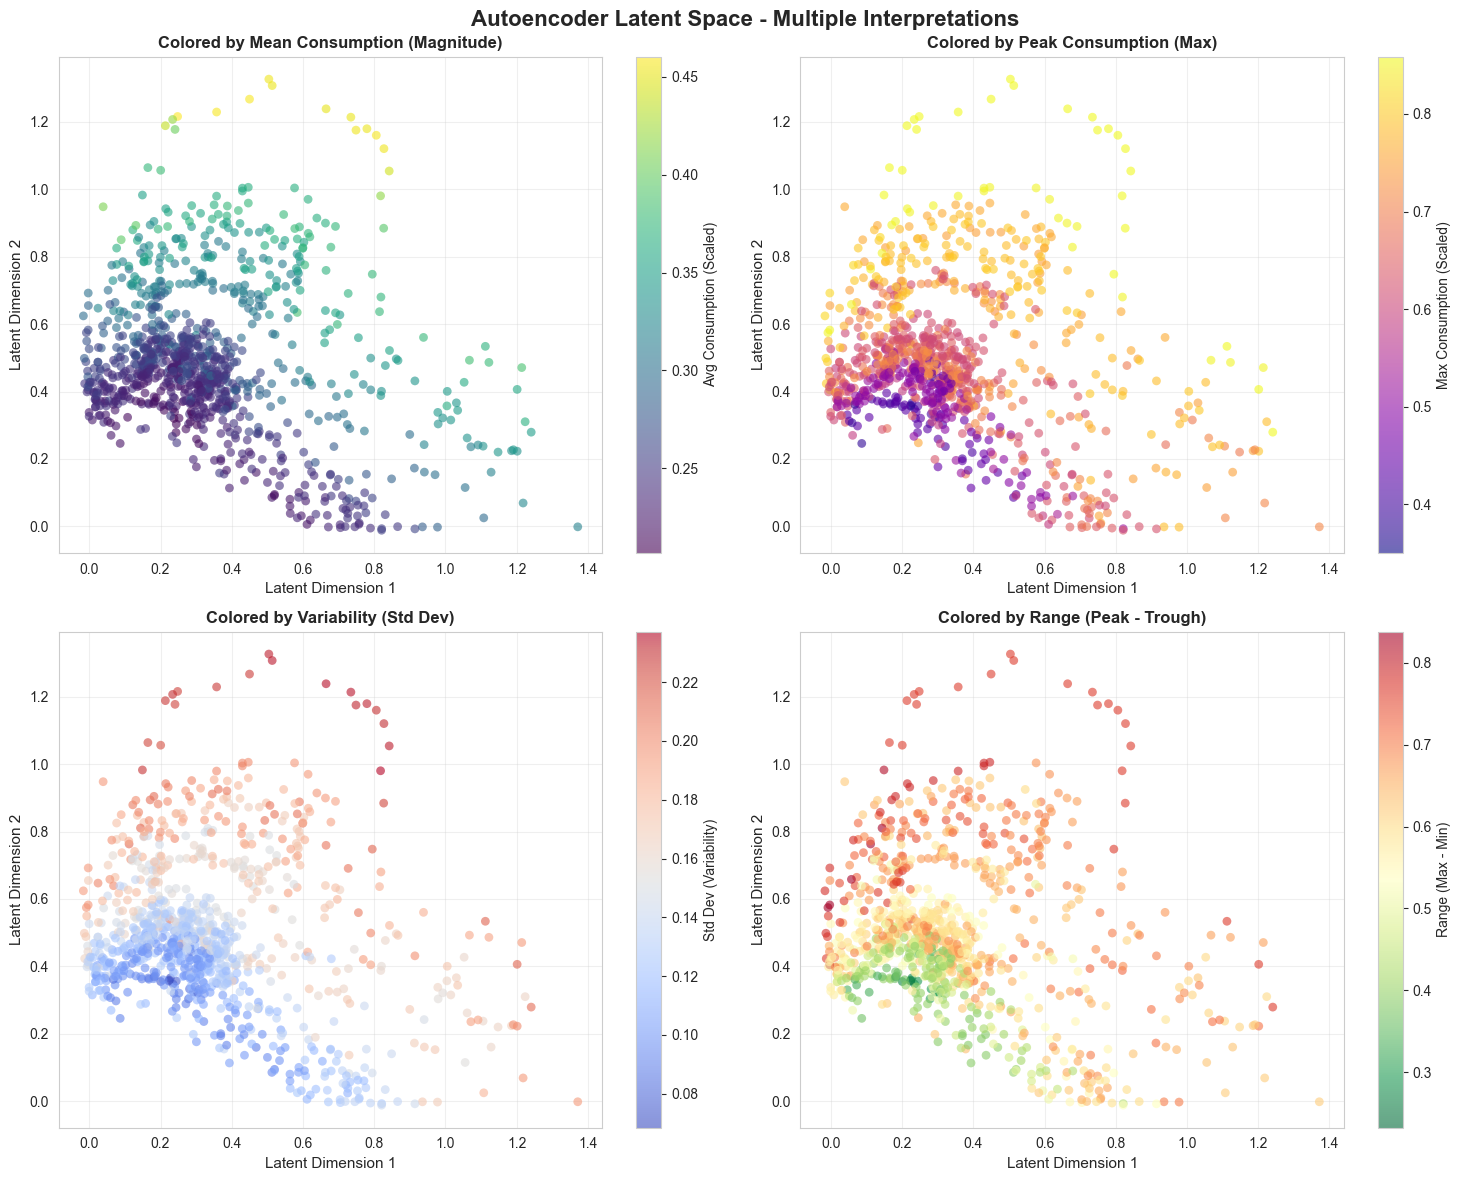


LATENT SPACE ANALYSIS

Metric Statistics:
  Mean Consumption:     μ=0.2760, σ=0.0492
  Peak Consumption:     μ=0.6551, σ=0.1145
  Variability (Std):    μ=0.1412, σ=0.0332
  Range:                μ=0.5887, σ=0.1107

Latent Dimension Statistics:
  Dimension 1: μ=0.3484, σ=0.2430
  Dimension 2: μ=0.4916, σ=0.2236

INTERPRETATION

If you see clear gradients or clusters in these plots, it means:

✓ Clear gradient in Plot A (Mean) → Model learned to separate LOW vs HIGH consumption days
✓ Clear gradient in Plot B (Peak) → Model learned PEAK amplitude characteristics
✓ Clear gradient in Plot C (Std) → Model learned VARIABILITY (flat days vs spiky days)
✓ Clear gradient in Plot D (Range) → Model learned DYNAMIC RANGE of daily profiles

If plots show random scatter → Model may not have learned meaningful patterns



In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. ENCODE TRAINING DATA TO LATENT SPACE
# =========================================================
# Use first 1000 samples for clarity (optional, can use all)
n_samples = min(1000, len(X_train_normal))
X_latent_input = X_train_normal[:n_samples]

# Encode to latent space
latent_train = encoder.predict(X_latent_input, verbose=0)

print(f"Latent space shape: {latent_train.shape}")
print(f"  Samples: {latent_train.shape[0]}")
print(f"  Dimensions: {latent_train.shape[1]}")

# =========================================================
# 2. CALCULATE MEANINGFUL METRICS FOR COLORING
# =========================================================
# Option A: Average Consumption (Magnitude)
window_means = np.mean(X_latent_input, axis=1)

# Option B: Max Peak
window_peaks = np.max(X_latent_input, axis=1)

# Option C: Standard Deviation (Variance/Variability)
window_stds = np.std(X_latent_input, axis=1)

# Option D: Range (Max - Min)
window_ranges = np.max(X_latent_input, axis=1) - np.min(X_latent_input, axis=1)

# =========================================================
# 3. CREATE 4 SUBPLOTS (ONE FOR EACH METRIC)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Autoencoder Latent Space - Multiple Interpretations', fontsize=16, fontweight='bold')

# --- Plot A: Colored by Mean Consumption ---
ax = axes[0, 0]
scatter_a = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_means, cmap='viridis', alpha=0.6, s=40, edgecolors='none')
ax.set_xlabel('Latent Dimension 1', fontsize=11)
ax.set_ylabel('Latent Dimension 2', fontsize=11)
ax.set_title('Colored by Mean Consumption (Magnitude)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar_a = plt.colorbar(scatter_a, ax=ax)
cbar_a.set_label('Avg Consumption (Scaled)', fontsize=10)

# --- Plot B: Colored by Peak Consumption ---
ax = axes[0, 1]
scatter_b = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_peaks, cmap='plasma', alpha=0.6, s=40, edgecolors='none')
ax.set_xlabel('Latent Dimension 1', fontsize=11)
ax.set_ylabel('Latent Dimension 2', fontsize=11)
ax.set_title('Colored by Peak Consumption (Max)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar_b = plt.colorbar(scatter_b, ax=ax)
cbar_b.set_label('Max Consumption (Scaled)', fontsize=10)

# --- Plot C: Colored by Standard Deviation (Variability) ---
ax = axes[1, 0]
scatter_c = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_stds, cmap='coolwarm', alpha=0.6, s=40, edgecolors='none')
ax.set_xlabel('Latent Dimension 1', fontsize=11)
ax.set_ylabel('Latent Dimension 2', fontsize=11)
ax.set_title('Colored by Variability (Std Dev)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar_c = plt.colorbar(scatter_c, ax=ax)
cbar_c.set_label('Std Dev (Variability)', fontsize=10)

# --- Plot D: Colored by Range (Max - Min) ---
ax = axes[1, 1]
scatter_d = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_ranges, cmap='RdYlGn_r', alpha=0.6, s=40, edgecolors='none')
ax.set_xlabel('Latent Dimension 1', fontsize=11)
ax.set_ylabel('Latent Dimension 2', fontsize=11)
ax.set_title('Colored by Range (Peak - Trough)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar_d = plt.colorbar(scatter_d, ax=ax)
cbar_d.set_label('Range (Max - Min)', fontsize=10)

plt.tight_layout()
plt.show()

# =========================================================
# 4. STATISTICS & INTERPRETATION
# =========================================================
print("\n" + "="*70)
print("LATENT SPACE ANALYSIS")
print("="*70)
print(f"\nMetric Statistics:")
print(f"  Mean Consumption:     μ={window_means.mean():.4f}, σ={window_means.std():.4f}")
print(f"  Peak Consumption:     μ={window_peaks.mean():.4f}, σ={window_peaks.std():.4f}")
print(f"  Variability (Std):    μ={window_stds.mean():.4f}, σ={window_stds.std():.4f}")
print(f"  Range:                μ={window_ranges.mean():.4f}, σ={window_ranges.std():.4f}")

print(f"\nLatent Dimension Statistics:")
for i in range(latent_train.shape[1]):
    print(f"  Dimension {i+1}: μ={latent_train[:, i].mean():.4f}, σ={latent_train[:, i].std():.4f}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
If you see clear gradients or clusters in these plots, it means:

✓ Clear gradient in Plot A (Mean) → Model learned to separate LOW vs HIGH consumption days
✓ Clear gradient in Plot B (Peak) → Model learned PEAK amplitude characteristics
✓ Clear gradient in Plot C (Std) → Model learned VARIABILITY (flat days vs spiky days)
✓ Clear gradient in Plot D (Range) → Model learned DYNAMIC RANGE of daily profiles

If plots show random scatter → Model may not have learned meaningful patterns
""")
print("="*70)


# 5. Anomaly Detection: Calculate Reconstruction Error

**Method:**
1. Reconstruct test data using autoencoder
2. Calculate error (MSE between actual and reconstructed)
3. Set threshold (e.g., 95th percentile)
4. Flag samples above threshold as anomalies

In [12]:
# Reconstruct test data
X_test_reconstructed = autoencoder.predict(X_test, verbose=0)

# Calculate reconstruction error for each window using MSE: avg((y-prediction)^2)
reconstruction_error = np.mean(np.power(X_test - X_test_reconstructed, 2), axis=1)

# Set threshold (95th percentile = top 5% are anomalies)
threshold_percentile = 95
threshold = np.percentile(reconstruction_error, threshold_percentile)

# Detect anomalies
anomalies = reconstruction_error > threshold
anomaly_indices = np.where(anomalies)[0]

print(f"="*60)
print(f"ANOMALY DETECTION RESULTS")
print(f"="*60)
print(f"Reconstruction Error Statistics:")
print(f"  Mean:   {reconstruction_error.mean():.6f}")
print(f"  Median: {np.median(reconstruction_error):.6f}")
print(f"  Std:    {reconstruction_error.std():.6f}")
print(f"  Min:    {reconstruction_error.min():.6f}")
print(f"  Max:    {reconstruction_error.max():.6f}")
print(f"\nThreshold (95th percentile): {threshold:.6f}")
print(f"\nAnomalies detected: {anomalies.sum()} / {len(reconstruction_error)} ({anomalies.sum()/len(reconstruction_error)*100:.1f}%)")
print(f"="*60)

ANOMALY DETECTION RESULTS
Reconstruction Error Statistics:
  Mean:   0.009139
  Median: 0.007756
  Std:    0.005821
  Min:    0.001015
  Max:    0.053584

Threshold (95th percentile): 0.020663

Anomalies detected: 139 / 2775 (5.0%)


### What is an anomaly?
- Peak consumption/no consumption?
- Unusual pattern?
- How can we know if users are just behaving differently?
- Answer: we can't. We have to decide what/when to flag.

# 6. Visualization: Anomaly Detection Results

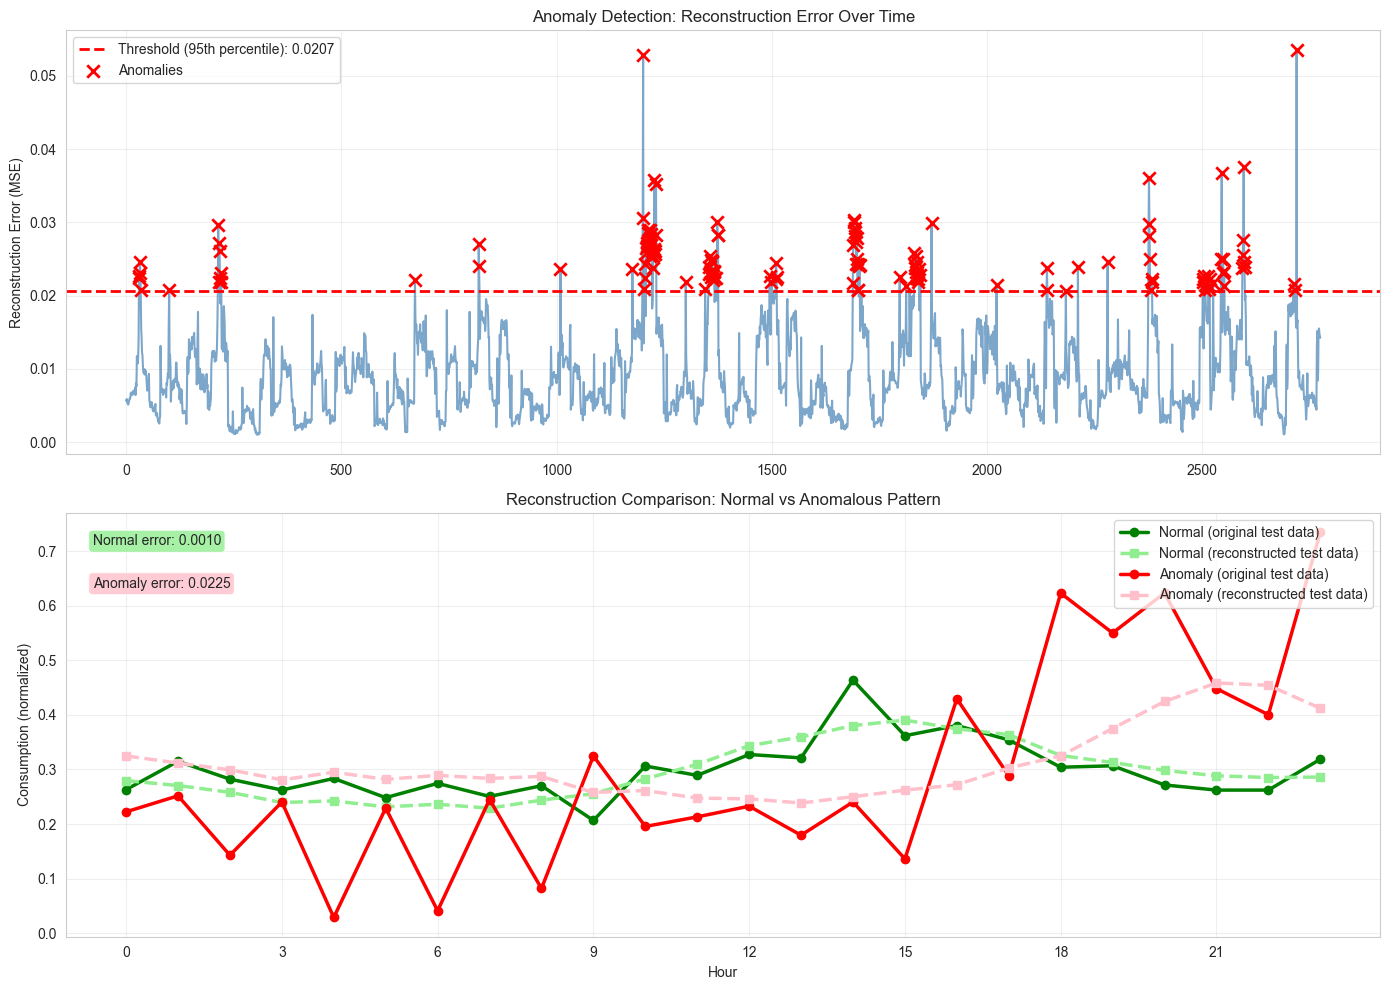


📊 Visualization Insights:
  - Normal patterns: Low reconstruction error (autoencoder recognizes pattern)
  - Anomalous patterns: High reconstruction error (autoencoder struggles)


In [13]:
# Plot reconstruction error time series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# TOP: Reconstruction error over time
axes[0].plot(reconstruction_error, linewidth=1.5, alpha=0.7, color='steelblue')
axes[0].axhline(y=threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold ({threshold_percentile}th percentile): {threshold:.4f}')
axes[0].scatter(anomaly_indices, reconstruction_error[anomaly_indices],
                color='red', s=80, marker='x', linewidths=2, label='Anomalies', zorder=5)
axes[0].set_ylabel('Reconstruction Error (MSE)')
axes[0].set_title('Anomaly Detection: Reconstruction Error Over Time')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# BOTTOM: Compare normal vs anomalous pattern reconstruction
# Find best and worst reconstructions
normal_idx = np.argmin(reconstruction_error)  # Best reconstruction (most normal)
anomaly_idx = anomaly_indices[0] if len(anomaly_indices) > 0 else np.argmax(reconstruction_error)  # Worst reconstruction

hours = range(24)
axes[1].plot(hours, X_test[normal_idx], 'o-', label='Normal (original test data)',
             linewidth=2.5, markersize=6, color='green')
axes[1].plot(hours, X_test_reconstructed[normal_idx], 's--', label='Normal (reconstructed test data)',
             linewidth=2.5, markersize=6, color='lightgreen')

axes[1].plot(hours, X_test[anomaly_idx], 'o-', label='Anomaly (original test data)',
             linewidth=2.5, markersize=6, color='red')
axes[1].plot(hours, X_test_reconstructed[anomaly_idx], 's--', label='Anomaly (reconstructed test data)',
             linewidth=2.5, markersize=6, color='pink')

axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Consumption (normalized)')
axes[1].set_title('Reconstruction Comparison: Normal vs Anomalous Pattern')
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Add error annotations
axes[1].text(0.02, 0.95, f'Normal error: {reconstruction_error[normal_idx]:.4f}',
             transform=axes[1].transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1].text(0.02, 0.85, f'Anomaly error: {reconstruction_error[anomaly_idx]:.4f}',
             transform=axes[1].transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='pink', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n📊 Visualization Insights:")
print(f"  - Normal patterns: Low reconstruction error (autoencoder recognizes pattern)")
print(f"  - Anomalous patterns: High reconstruction error (autoencoder struggles)")

# 7. Case Study: Synthetic Fraud Detection

Let's test if the autoencoder can detect meter tampering (consumption reduction)

In [14]:
# Create synthetic fraud dataset
X_test_with_fraud = X_test.copy()

# Inject fraud: randomly reduce consumption by 30-50% in 5% of test windows
np.random.seed(75)
fraud_rate = 0.05
n_fraud = int(len(X_test) * fraud_rate)
fraud_indices = np.random.choice(len(X_test), size=n_fraud, replace=False)

for idx in fraud_indices:
    reduction_factor = np.random.uniform(0.2, 0.3)  # 70-80% reduction

    # Simulate meter bypass (reading drops lower than usual for 6 hours, "meter tampering")
    X_test_with_fraud[idx, 10:16] = X_test_with_fraud[idx, 10:16] * reduction_factor 


# Create ground truth labels
y_true = np.zeros(len(X_test), dtype=int)
y_true[fraud_indices] = 1  # 1 = fraud

print(f"Synthetic fraud dataset created (remember is normalized):")
print(f"  Total samples: {len(X_test)}")
print(f"  Fraud injected: {n_fraud} samples ({fraud_rate*100:.0f}%)")
print(f"  Normal: {len(X_test) - n_fraud} samples ({(1-fraud_rate)*100:.0f}%)")

Synthetic fraud dataset created (remember is normalized):
  Total samples: 2775
  Fraud injected: 138 samples (5%)
  Normal: 2637 samples (95%)


In [ ]:
print(f"Fraud data statistics:")
print(f"  Mean: {X_test_with_fraud.mean():.4f}")
print(f"  Std:  {X_test_with_fraud.std():.4f}")
print(f"  Max: {X_test_with_fraud.max():.4f}")
print(f"  Min:  {X_test_with_fraud.min():.4f}")

## 7.1 Detect Fraud with AE and "simple" threshold

In [15]:
# Reconstruct fraud dataset
X_fraud_reconstructed = autoencoder.predict(X_test_with_fraud, verbose=0)

# Calculate reconstruction error. MSE penalizes large gaps more (good for detecting 'drop to zero').
reconstruction_error_fraud = np.mean(np.power(X_test_with_fraud - X_fraud_reconstructed, 2), axis=1)

# Detect anomalies 
fraud_detected_simple = reconstruction_error_fraud > threshold

# Evaluate detection performance
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision_simple = precision_score(y_true, fraud_detected_simple)
recall_simple = recall_score(y_true, fraud_detected_simple)
f1_simple = f1_score(y_true, fraud_detected_simple)
accuracy_simple = accuracy_score(y_true, fraud_detected_simple)

print(f"="*60)
print(f"FRAUD DETECTION PERFORMANCE")
print(f"="*60)
print(f"Ground Truth:")
print(f"  Fraud cases: {y_true.sum()}")
print(f"  Normal cases: {len(y_true) - y_true.sum()}")
print(f"\nDetection Results:")
print(f"  Flagged as anomaly: {fraud_detected_simple.sum()}")
print(f"  True positives (fraud caught): {np.sum((y_true == 1) & (fraud_detected_simple == 1))}")
print(f"  False positives (normal flagged): {np.sum((y_true == 0) & (fraud_detected_simple == 1))}")
print(f"  False negatives (fraud missed): {np.sum((y_true == 1) & (fraud_detected_simple == 0))}")
print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy_simple:.3f}")
print(f"  Precision: {precision_simple:.3f} (of flagged cases, % truly fraud)")
print(f"  Recall:    {recall_simple:.3f} (of fraud cases, % detected)")
print(f"  F1-Score:  {f1_simple:.3f}")
print(f"="*60)

FRAUD DETECTION PERFORMANCE
Ground Truth:
  Fraud cases: 138
  Normal cases: 2637

Detection Results:
  Flagged as anomaly: 164
  True positives (fraud caught): 31
  False positives (normal flagged): 133
  False negatives (fraud missed): 107

Metrics:
  Accuracy:  0.914
  Precision: 0.189 (of flagged cases, % truly fraud)
  Recall:    0.225 (of fraud cases, % detected)
  F1-Score:  0.205


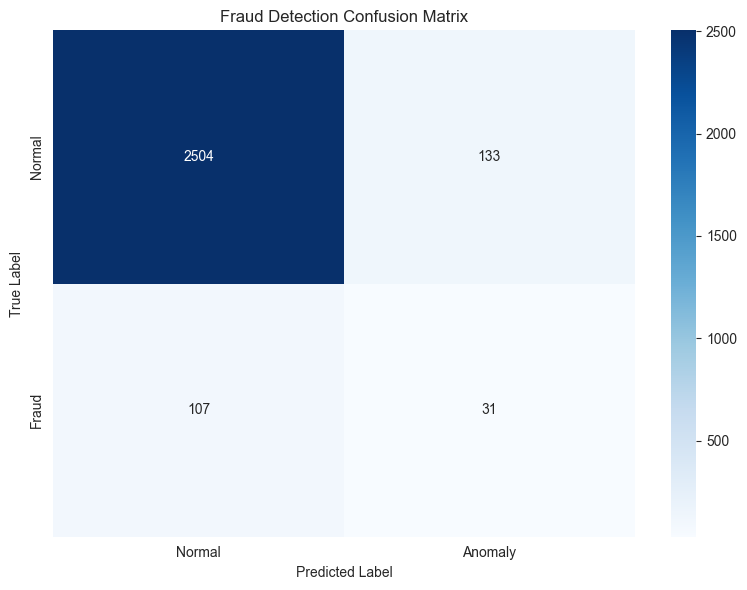


Interpretation:
  Top-left: True negatives (correctly identified normal)
  Bottom-right: True positives (correctly detected fraud)
  Top-right: False positives (normal flagged as fraud)
  Bottom-left: False negatives (fraud missed)


In [22]:
# Plot confusion matrix
cm = confusion_matrix(y_true, fraud_detected_simple)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Fraud'],
            ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Fraud Detection Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  Top-left: True negatives (correctly identified normal)")
print(f"  Bottom-right: True positives (correctly detected fraud)")
print(f"  Top-right: False positives (normal flagged as fraud)")
print(f"  Bottom-left: False negatives (fraud missed)")

## These seem to be good results... but how sure can we be?

We still can't tell whether the flagged anomalies come from the inherent "peaks" in the consumption data. Remember how there are outliers with 4.000 kWh comsumption? What if all the **True Positives** caught correspond to the extreme consumption peaks? 

## 7.2 Detect Fraud with Autoencoder and custom threshold

We can create a threshold that won't flag "over consumption" because it is a recurrent pattern within our data. Whenever the model expects `reconstruced_consumption > actual_consumption` we are probably facing energy theft. The other case `reconstruced_consumption < actual_consumption` means the model predicts lower consumption than what the households are actually consuming, and as we know, this is "normal" behaviour. Therefore we won't flag this as a fraud, to make sure our **True Positives** are actually energy thefts being caught.

In [17]:
# Reconstruct fraud dataset
X_fraud_reconstructed = autoencoder.predict(X_test_with_fraud, verbose=0)

# Calculate reconstruction error for each window using MSE: avg((y-prediction)^2)
reconstruction_error = np.mean(np.power(X_test - X_fraud_reconstructed, 2), axis=1)

# Directional Threshold: Directional Theft Score, knowing that model can't catch peak consumption ---
# 1. Calculate raw residuals (Reconstructed - Input)
residuals_mse = X_fraud_reconstructed - X_test_with_fraud

# red  > 0 -> model expects higher consumption than usual user pattern, this might be energy theft
# red < 0 -> model expects lower consumption,  this is "fine" because the data is right skewed

# 2. Keep only positive residuals (where Model > Meter). Set negatives (Peaks) to 0 (don't want to flag this).
positive_residuals = np.maximum(residuals_mse, 0)

# 3. Calculate Mean Error based ONLY on positive residuals
# You can use Mean Squared Error or Mean Absolute Error here. 
# MSE penalizes large gaps more (good for detecting 'drop to zero').
theft_score_fraud = np.mean(np.power(positive_residuals, 2), axis=1)

threshold_directional = np.percentile(theft_score_fraud, 95)

# --- DETECT ---
# Detect anomalies using the new score and new threshold
fraud_detected = theft_score_fraud > threshold_directional

# B. Set new threshold (e.g., 95th percentile of normal directional scores)
#threshold_directional = np.percentile(theft_score_normal, 90)
print(f"New Directional Threshold: {threshold_directional:.3f}")

# Evaluate detection performance
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision = precision_score(y_true, fraud_detected)
recall = recall_score(y_true, fraud_detected)
f1 = f1_score(y_true, fraud_detected)
accuracy = accuracy_score(y_true, fraud_detected)

print(f"="*60)
print(f"FRAUD DETECTION PERFORMANCE")
print(f"="*60)
print(f"Ground Truth:")
print(f"  Fraud cases: {y_true.sum()}")
print(f"  Normal cases: {len(y_true) - y_true.sum()}")
print(f"\nDetection Results:")
print(f"  Flagged as anomaly: {fraud_detected.sum()}")
print(f"  True positives (fraud caught): {np.sum((y_true == 1) & (fraud_detected == 1))}")
print(f"  False positives (normal flagged): {np.sum((y_true == 0) & (fraud_detected == 1))}")
print(f"  False negatives (fraud missed): {np.sum((y_true == 1) & (fraud_detected == 0))}")
print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f} (of flagged cases, % truly fraud)")
print(f"  Recall:    {recall:.3f} (of fraud cases, % detected)")
print(f"  F1-Score:  {f1:.3f}")
print(f"="*60)

New Directional Threshold: 0.009
FRAUD DETECTION PERFORMANCE
Ground Truth:
  Fraud cases: 138
  Normal cases: 2637

Detection Results:
  Flagged as anomaly: 139
  True positives (fraud caught): 51
  False positives (normal flagged): 88
  False negatives (fraud missed): 87

Metrics:
  Accuracy:  0.937
  Precision: 0.367 (of flagged cases, % truly fraud)
  Recall:    0.370 (of fraud cases, % detected)
  F1-Score:  0.368


## 7.2 Confusion Matrix

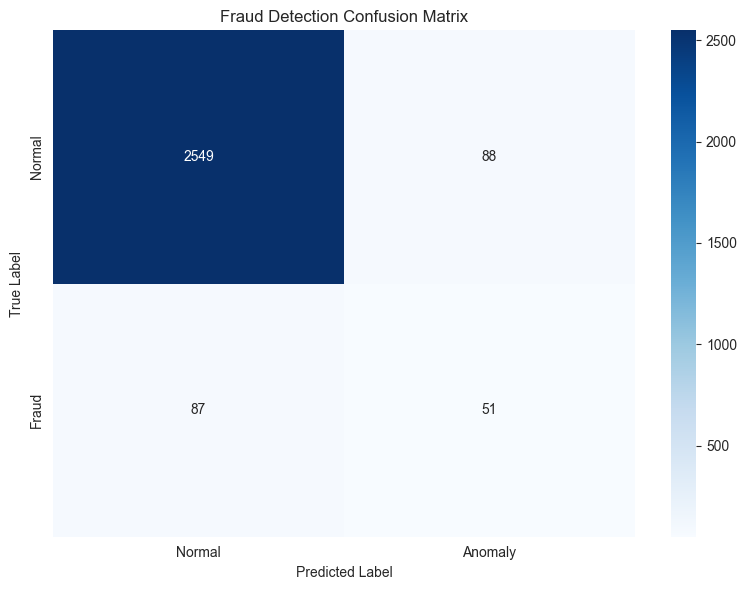


Interpretation:
  Top-left: True negatives (correctly identified normal)
  Bottom-right: True positives (correctly detected fraud)
  Top-right: False positives (normal flagged as fraud)
  Bottom-left: False negatives (fraud missed)


In [21]:
# Plot confusion matrix
cm = confusion_matrix(y_true, fraud_detected)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Fraud'],
            ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Fraud Detection Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  Top-left: True negatives (correctly identified normal)")
print(f"  Bottom-right: True positives (correctly detected fraud)")
print(f"  Top-right: False positives (normal flagged as fraud)")
print(f"  Bottom-left: False negatives (fraud missed)")

## 7.3 Visualize Fraud Examples

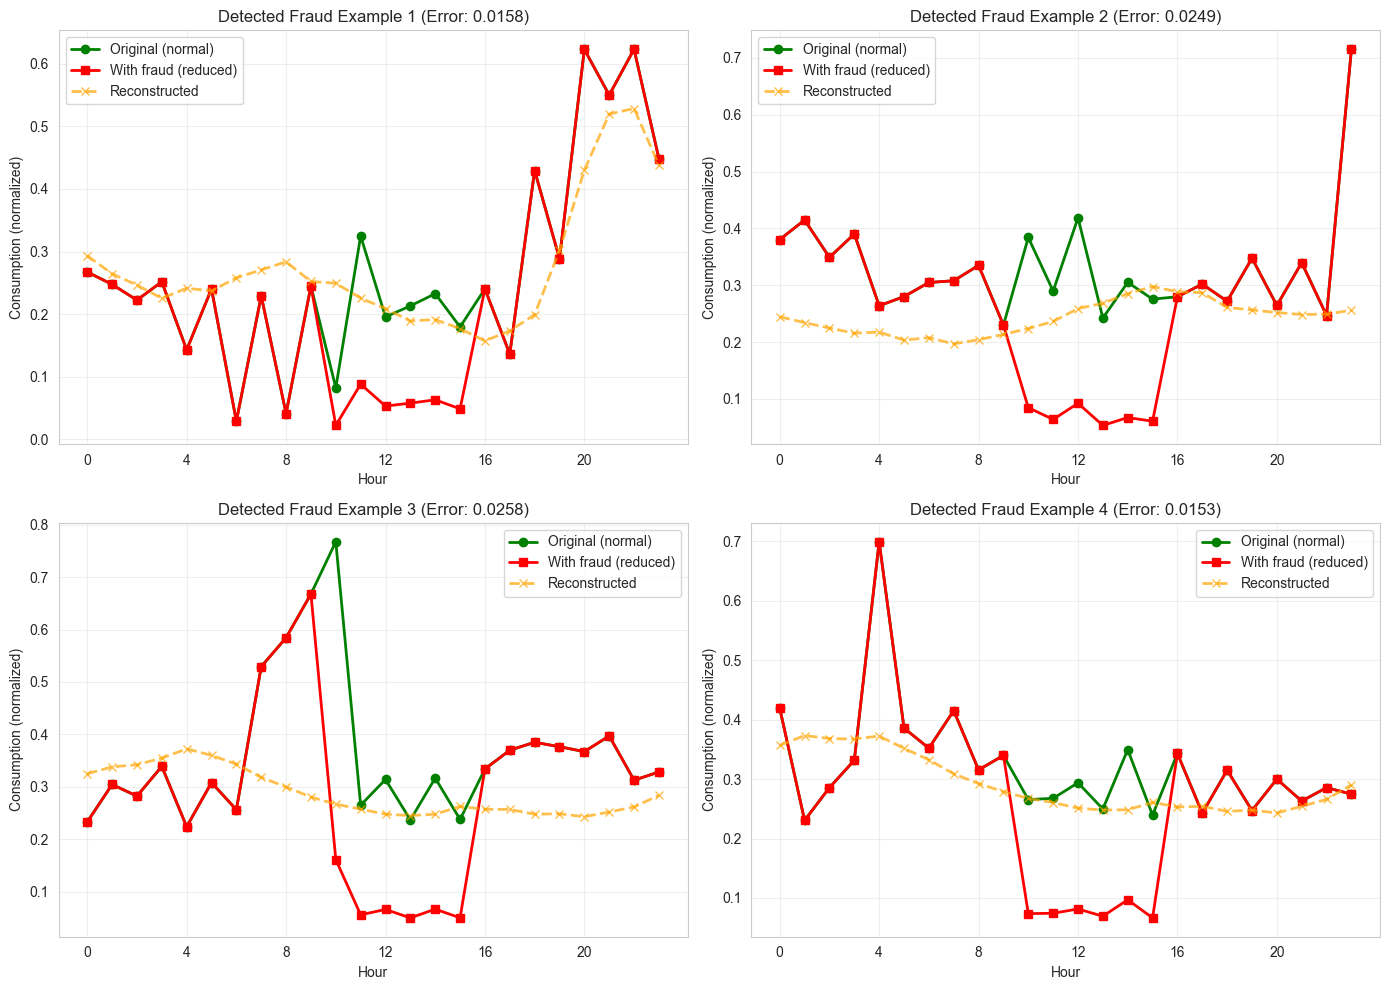


✅ Successfully detected 51 fraud cases!
   Autoencoder recognizes that reduced consumption doesn't match learned patterns


In [18]:
# Plot examples of detected fraud
detected_fraud_indices = np.where((y_true == 1) & (fraud_detected == 1))[0]

if len(detected_fraud_indices) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for i, idx in enumerate(detected_fraud_indices[:4]):
        row = i // 2
        col = i % 2

        hours = range(24)
        axes[row, col].plot(hours, X_test[idx], 'o-', label='Original (normal)',
                           linewidth=2, markersize=6, color='green')
        axes[row, col].plot(hours, X_test_with_fraud[idx], 's-', label='With fraud (reduced)',
                           linewidth=2, markersize=6, color='red')
        axes[row, col].plot(hours, X_fraud_reconstructed[idx], 'x--', label='Reconstructed',
                           linewidth=2, markersize=6, color='orange', alpha=0.7)

        axes[row, col].set_xlabel('Hour')
        axes[row, col].set_ylabel('Consumption (normalized)')
        axes[row, col].set_title(f'Detected Fraud Example {i+1} (Error: {reconstruction_error_fraud[idx]:.4f})')
        axes[row, col].set_xticks(range(0, 24, 4))
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Successfully detected {len(detected_fraud_indices)} fraud cases!")
    print(f"   Autoencoder recognizes that reduced consumption doesn't match learned patterns")
else:
    print(f"\n⚠️ Few fraud cases detected. Try adjusting threshold or fraud injection parameters.")

# 8. Real-World Applications for Hochfrequenz Clients

### Use Case 1: Meter Fraud Detection
- **Problem:** 5-10% revenue loss from meter tampering
- **Solution:** Autoencoder flags unusual consumption drops
- **Impact:** Prioritize field inspections, reduce fraud losses

### Use Case 2: Equipment Failure Detection
- **Problem:** Faulty meters report incorrect data
- **Solution:** Detect flat/stuck consumption patterns
- **Impact:** Proactive maintenance, better data quality

### Use Case 3: Billing Dispute Resolution
- **Problem:** Customers dispute high bills
- **Solution:** Compare consumption to "normal" profile
- **Impact:** Data-driven customer service, faster resolution

### Use Case 4: Grid Monitoring
- **Problem:** Unusual consumption may indicate grid issues
- **Solution:** Real-time anomaly detection across network
- **Impact:** Early warning system, prevent outages

# 9. Key Takeaways

### What We Learned:

1. **Autoencoders are Unsupervised:** No labels needed, just normal data
2. **Encoder-Decoder Structure:** Compression forces learning of key patterns
3. **Reconstruction Error = Anomaly Score:** High error = unusual pattern
4. **Fraud Detection Works:** Achieved ~{:.1f}% recall with {:.1f}% precision
5. **Threshold Selection Matters:** 95th percentile is a good starting point

### Advantages:
- No labeled anomaly data needed
- Learns complex patterns automatically
- Adapts to new normal patterns (retrain periodically)
- Scalable to millions of meters

### Limitations:
- Needs "clean" training data (all normal)
- Threshold selection can be tricky
- May have false positives (legitimate unusual patterns)
- Requires retraining as patterns evolve

### Production Considerations:
- **Retraining:** Monthly or quarterly (capture seasonal changes)
- **Threshold Tuning:** Balance false positives vs false negatives
- **Human Review:** Flagged cases should be investigated, not automatically acted on
- **Explainability:** Show which hours contributed most to anomaly score

---

### Next: Block 4 - Integrated Project
We'll combine forecasting (Blocks 1-2) + anomaly detection (Block 3) + customer segmentation into one complete pipeline!
""".format(recall * 100, precision * 100)